In [1]:
import os
import sys
import torch
import torchvision

from torch import optim
# from torchvision.transforms import GaussianBlur, Resize

from optical_volume import optics, scene, utils
# from py_wave_propagator import torch_volume_prop as propagator

from matplotlib import pyplot as plt

In [10]:
# example: functioning
WL = 500e-9
OBJ_SPACING = [100e-9, 100e-9, 100e-9]
SHAPE = [600, 600, 100]
NA = 0.7
DIST_PM_IM = 1.43e-3

TILE_LEN = 12e-6
PM_HEIGHT = 100e-9
PM_RI = 1.46
PM_SIG = 0.6

N_BG = 1.51
PAD = 512
FOC_PLANE_VAR = 0.1e-8

MAG = 40
OBJ_IMG_FACTOR = 20
EFF_MAG = int(40/20)

IMG_SPACING = [OBJ_SPACING[i]*OBJ_IMG_FACTOR for i in range(2)]
DIGITAL_PX = 6e-6
SUM_PATCH = int(DIGITAL_PX/IMG_SPACING[0])

DEVICE = 'cuda:1'


ell_1 = scene.shapes.Ellipsoid(torch.tensor((10e-6, 30e-6, 5e-6)).float(), torch.tensor((5e-6, 9e-6, 3e-6)), torch.tensor(1.46), softness=1e-12)
ell_2 = scene.shapes.Ellipsoid(torch.tensor((30e-6, 30e-6, 5e-6)).float(), torch.tensor((9e-6, 3e-6, 5e-6)), torch.tensor(1.46), softness=1e-12)
ell_3 = scene.shapes.Ellipsoid(torch.tensor((50e-6, 30e-6, 5e-6)).float(), torch.tensor((5e-6, 3e-6, 5e-6)), torch.tensor(1.46), softness=1e-12)

vol = scene.CollectionVolume(SHAPE, OBJ_SPACING, N_BG)

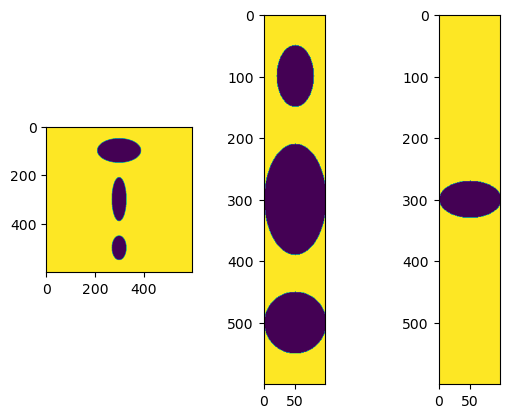

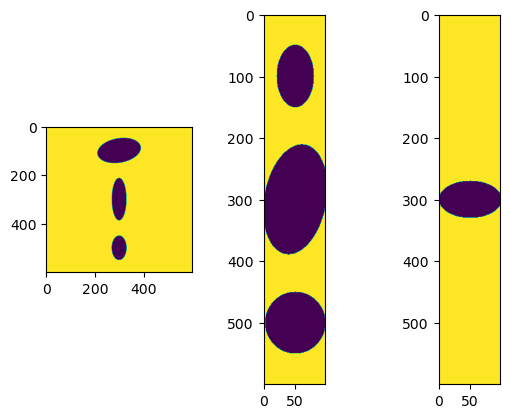

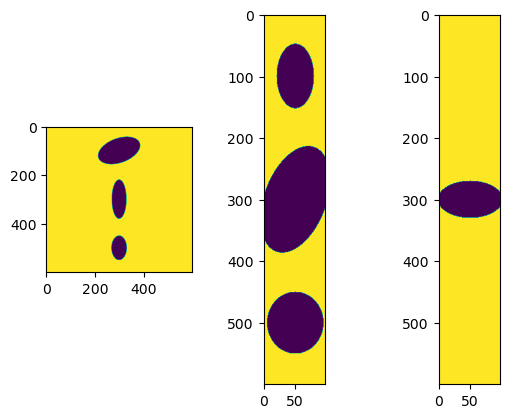

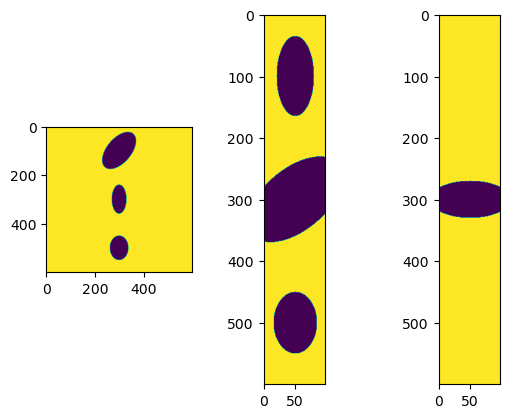

In [12]:
for rot in [0, 10, 20, 50]:
    ell_1.set_quat((0, 0, 1), rot)
    ell_2.set_quat((0, 1, 0), rot)
    ell_3.set_quat((1, 0, 0), rot)

    vol.add([ell_1, ell_2, ell_3])
    ri_dist = vol.forward()

    fig, axs = plt.subplots(1, 3)
    axs[0].imshow(ri_dist[:, :, 50].detach().cpu())
    axs[1].imshow(ri_dist[:, 300, :].detach().cpu())
    axs[2].imshow(ri_dist[300, :, :].detach().cpu())

    plt.show()